<a target="_blank" href="https://colab.research.google.com/github/AI4Finance-Foundation/FinRL-Tutorials/blob/master/2-Advance/FinRL_Ensemble_StockTrading_ICAIF_2020.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Deep Reinforcement Learning for Stock Trading from Scratch: Multiple Stock Trading Using Ensemble Strategy

Tutorials to use OpenAI DRL to trade multiple stocks using ensemble strategy in one Jupyter Notebook | Presented at ICAIF 2020

* This notebook is the reimplementation of our paper: Deep Reinforcement Learning for Automated Stock Trading: An Ensemble Strategy, using FinRL.
* Check out medium blog for detailed explanations: https://medium.com/@ai4finance/deep-reinforcement-learning-for-automated-stock-trading-f1dad0126a02
* Please report any issues to our Github: https://github.com/AI4Finance-LLC/FinRL-Library/issues
* **Pytorch Version**



# Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Python packages](#1)
    * [2.1. Install Packages](#1.1)    
    * [2.2. Check Additional Packages](#1.2)
    * [2.3. Import Packages](#1.3)
    * [2.4. Create Folders](#1.4)
* [3. Download Data](#2)
* [4. Preprocess Data](#3)        
    * [4.1. Technical Indicators](#3.1)
    * [4.2. Perform Feature Engineering](#3.2)
* [5.Build Environment](#4)  
    * [5.1. Training & Trade Data Split](#4.1)
    * [5.2. User-defined Environment](#4.2)   
    * [5.3. Initialize Environment](#4.3)    
* [6.Implement DRL Algorithms](#5)  
* [7.Backtesting Performance](#6)  
    * [7.1. BackTestStats](#6.1)
    * [7.2. BackTestPlot](#6.2)   
    * [7.3. Baseline Stats](#6.3)   
    * [7.3. Compare to Stock Market Index](#6.4)             

<a id='0'></a>
# Part 1. Problem Definition

This problem is to design an automated trading solution for single stock trading. We model the stock trading process as a Markov Decision Process (MDP). We then formulate our trading goal as a maximization problem.

The algorithm is trained using Deep Reinforcement Learning (DRL) algorithms and the components of the reinforcement learning environment are:


* Action: The action space describes the allowed actions that the agent interacts with the
environment. Normally, a ∈ A includes three actions: a ∈ {−1, 0, 1}, where −1, 0, 1 represent
selling, holding, and buying one stock. Also, an action can be carried upon multiple shares. We use
an action space {−k, ..., −1, 0, 1, ..., k}, where k denotes the number of shares. For example, "Buy
10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or −10, respectively

* Reward function: r(s, a, s′) is the incentive mechanism for an agent to learn a better action. The change of the portfolio value when action a is taken at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio
values at state s′ and s, respectively

* State: The state space describes the observations that the agent receives from the environment. Just as a human trader needs to analyze various information before executing a trade, so
our trading agent observes many different features to better learn in an interactive environment.

* Environment: Dow 30 consituents


The data of the single stock that we will be using for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.


<a id='1'></a>
# Part 2. Getting Started- Load Python Packages

<a id='1.1'></a>
## 2.1. Install all the packages through FinRL library


In [ ]:
# ## install finrl library
#!pip install wrds
#!pip install swig
#!pip install -q condacolab
#import condacolab
#condacolab.install()
#!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
#!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git



<a id='1.2'></a>
## 2.2. Check if the additional packages needed are present, if not install them.
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

<a id='1.3'></a>
## 2.3. Import Packages

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Suppress stable-baselines3 logging warnings
import logging

# Suppress all stable_baselines3 loggers
logging.getLogger('stable_baselines3').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.common.logger').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.ddpg').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.td3').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.sac').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.a2c').setLevel(logging.ERROR)
logging.getLogger('stable_baselines3.ppo').setLevel(logging.ERROR)

# Suppress gym logger as well
logging.getLogger('gym').setLevel(logging.ERROR)

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.config_tickers import DOW_30_TICKER
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent,DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import sys
sys.path.append("../FinRL-Library")

import itertools

<a id='1.4'></a>
## 2.4. Create Folders

In [3]:
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)

check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

<a id='2'></a>
# Part 3. Download Data
Yahoo Finance is a website that provides stock data, financial news, financial reports, etc. All the data provided by Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** to fetch data from Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).




-----
class YahooDownloader:
    Provides methods for retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from config.py)
        end_date : str
            end date of the data (modified from config.py)
        ticker_list : list
            a list of stock tickers (modified from config.py)

    Methods
    -------
    fetch_data()
        Fetches data from yahoo API


In [4]:
print(DOW_30_TICKER)

['AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CSCO', 'CVX', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'KO', 'JPM', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'CRM', 'VZ', 'V', 'WBA', 'WMT', 'DIS', 'DOW']


In [5]:
# TRAIN_START_DATE = '2009-04-01'
# TRAIN_END_DATE = '2021-01-01'
# TEST_START_DATE = '2021-01-01'
# TEST_END_DATE = '2022-06-01'
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.config_tickers import DOW_30_TICKER

TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2023-10-01'
TEST_START_DATE = '2023-10-02'
TEST_END_DATE = '2025-10-01'
ticker_list = [ticker for ticker in DOW_30_TICKER if ticker != 'WBA']
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TEST_END_DATE,
                     ticker_list = ticker_list).fetch_data()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (112523, 8)


# Part 4: Preprocess Data
Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: MACD and RSI.
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

In [6]:
INDICATORS = ['macd',
               'rsi_30',
               'cci_30',
               'dx_30']

In [7]:
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df)
processed = processed.copy()
processed = processed.fillna(0)
processed = processed.replace(np.inf,0)

Successfully added technical indicators
Successfully added turbulence index


<a id='4'></a>
# Part 5. Design Environment
Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.

The action space describes the allowed actions that the agent interacts with the environment. Normally, action a includes three actions: {-1, 0, 1}, where -1, 0, 1 represent selling, holding, and buying one share. Also, an action can be carried upon multiple shares. We use an action space {-k,…,-1, 0, 1, …, k}, where k denotes the number of shares to buy and -k denotes the number of shares to sell. For example, "Buy 10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or -10, respectively. The continuous action space needs to be normalized to [-1, 1], since the policy is defined on a Gaussian distribution, which needs to be normalized and symmetric.

In [8]:
stock_dimension = len(processed.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")


Stock Dimension: 28, State Space: 169


In [19]:
buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

# Environment kwargs for DRLEnsembleAgent 
# IMPORTANT: DRLEnsembleAgent requires SCALAR values for buy_cost_pct and sell_cost_pct
# (not lists), because it creates its own StockTradingEnv internally
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": 0.001,  # Scalar for DRLEnsembleAgent
    "sell_cost_pct": 0.001,  # Scalar for DRLEnsembleAgent
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity": 5
}

# Environment kwargs for direct StockTradingEnv creation (e.g., in Bayesian optimization)
# Uses LISTS for buy_cost_pct/sell_cost_pct (per-stock costs) and includes num_stock_shares
env_kwargs_with_shares = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,  # List for direct StockTradingEnv
    "sell_cost_pct": sell_cost_list,  # List for direct StockTradingEnv
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity": 5
}

<a id='7'></a>
# Part 7: Implement DRL Algorithms and Run Ensemble Strategy
* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

* In this notebook, we are training and validating 5 agents (A2C, PPO, DDPG, SAC, TD3) using Rolling-window Ensemble Method ([reference code](https://github.com/AI4Finance-LLC/Deep-Reinforcement-Learning-for-Automated-Stock-Trading-Ensemble-Strategy-ICAIF-2020/blob/80415db8fa7b2179df6bd7e81ce4fe8dbf913806/model/models.py#L92))

In [20]:
rebalance_window = 63 # rebalance_window is the number of days to retrain the model
validation_window = 63 # validation_window is the number of days to do validation and trading (e.g. if validation_window=63, then both validation and trading period will be 63 days)

ensemble_agent = DRLEnsembleAgent(df=processed,
                 train_period=(TRAIN_START_DATE,TRAIN_END_DATE),
                 val_test_period=(TEST_START_DATE,TEST_END_DATE),
                 rebalance_window=rebalance_window,
                 validation_window=validation_window,
                 **env_kwargs)
# e_train_gym = StockTradingEnv(df = processed, **env_kwargs)
# agent = DRLAgent(e_train_gym)
# if_using_a2c = True
# model_a2c = agent.get_model("a2c")
# # if if_using_a2c:
# #   tmp_path = RESULTS_DIR + '/a2c'
# #   new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
# #   model_a2c.set_logger(new_logger_a2c)
# trained_a2c = agent.train_model(model=model_a2c,
#                              tb_log_name='a2c',
#                              total_timesteps=50000)

<a id='5.5'></a>
## 5.5 Hyperparameter Optimization (Optional)

This section implements Bayesian optimization using Optuna to find optimal hyperparameters for each DRL algorithm. The optimization uses the first rolling window for training and validation to determine the best hyperparameters, which can then be used for the full ensemble strategy.

**Note**: This is computationally intensive. You can skip this section and use the default parameters, or run a reduced number of trials.

In [ ]:
# Install optuna if not already installed
try:
    import optuna
    print(f"Optuna version: {optuna.__version__}")
except ImportError:
    print("Installing optuna...")
    !pip install optuna
    import optuna
    print("Optuna installed successfully!")

In [ ]:
# ============================================================================
# Prepare data for Bayesian Hyperparameter Optimization
# ============================================================================
# IMPORTANT: This is separate from the ensemble rolling window strategy!
# 
# Strategy:
#   - Use substantial historical data for finding optimal hyperparameters
#   - Training: 2010-2019 (10 years) - diverse market conditions
#   - Validation: 2020-2021 (21 months) - includes COVID crash for robustness
#   - Test: 2021-2023 (reserved) - final evaluation with rolling windows
#
# The rebalance_window (63 days) is for the ENSEMBLE STRATEGY, not for
# hyperparameter optimization data splits!
# ============================================================================

# Define date ranges for Bayesian optimization
BAYES_TRAIN_START = '2010-01-01'
BAYES_TRAIN_END = '2019-12-31'      # 10 years for training
BAYES_VAL_START = '2020-01-01'
BAYES_VAL_END = '2021-09-30'        # 21 months for validation (includes COVID)

# Note: TEST_START_DATE and TEST_END_DATE are reserved for final testing

# Split data for hyperparameter optimization
# Use factorize() to create day-based index (FinRL pattern)
# This creates non-unique index where each day number appears stock_dim times
hp_train_data = processed[
    (processed.date >= BAYES_TRAIN_START) & 
    (processed.date < BAYES_TRAIN_END)
].copy()
hp_train_data = hp_train_data.sort_values(['date', 'tic'], ignore_index=True)
hp_train_data.index = hp_train_data.date.factorize()[0]  # Day-based index: [0,0,0...29x, 1,1,1...29x, ...]

hp_val_data = processed[
    (processed.date >= BAYES_VAL_START) & 
    (processed.date < BAYES_VAL_END)
].copy()
hp_val_data = hp_val_data.sort_values(['date', 'tic'], ignore_index=True)
hp_val_data.index = hp_val_data.date.factorize()[0]  # Day-based index: [0,0,0...29x, 1,1,1...29x, ...]

# Display data allocation summary
print("=" * 80)
print("BAYESIAN OPTIMIZATION DATA ALLOCATION")
print("=" * 80)
print(f"\n📊 Training Period:")
print(f"   Dates: {BAYES_TRAIN_START} to {BAYES_TRAIN_END}")
print(f"   Duration: ~10 years")
print(f"   Unique trading days: {hp_train_data.date.nunique()}")
print(f"   Data shape: {hp_train_data.shape}")
print(f"   Tickers: {hp_train_data.tic.nunique()}")

print(f"\n📊 Validation Period:")
print(f"   Dates: {BAYES_VAL_START} to {BAYES_VAL_END}")
print(f"   Duration: ~21 months (includes COVID-19 crash)")
print(f"   Unique trading days: {hp_val_data.date.nunique()}")
print(f"   Data shape: {hp_val_data.shape}")
print(f"   Tickers: {hp_val_data.tic.nunique()}")

print(f"\n📊 Reserved Test Period (for ensemble strategy):")
print(f"   Dates: {TEST_START_DATE} to {TEST_END_DATE}")
print(f"   Note: Will use 63-day rolling windows AFTER hyperparameter optimization")

print("\n" + "=" * 80)
print("CONCEPTUAL FLOW:")
print("=" * 80)
print("1. Bayesian Optimization (this section):")
print("   → Find optimal hyperparameters using 10 years training + 21 months validation")
print("\n2. Ensemble Strategy (next section):")
print("   → Use optimized hyperparameters with 63-day rolling windows on test period")
print("\n" + "=" * 80)

# Verify data quality
print("\n✓ Data Quality Checks:")
print(f"  - Training data has no nulls: {not hp_train_data.isnull().any().any()}")
print(f"  - Validation data has no nulls: {not hp_val_data.isnull().any().any()}")
print(f"  - Training data has no infs: {not np.isinf(hp_train_data.select_dtypes(include=[np.number])).any().any()}")
print(f"  - Validation data has no infs: {not np.isinf(hp_val_data.select_dtypes(include=[np.number])).any().any()}")
print(f"\n  Technical indicators in data: {[col for col in INDICATORS if col in hp_train_data.columns]}")

In [11]:
# Helper function to calculate validation Sharpe ratio
def calculate_validation_sharpe(model, validation_data, validation_env):
    """
    Calculate Sharpe ratio on validation data
    """
    try:
        df_account_value, df_actions = DRLAgent.DRL_prediction(
            model=model,
            environment=validation_env
        )
        
        # Ensure df_account_value is a DataFrame and has the expected structure
        if not isinstance(df_account_value, pd.DataFrame):
            print(f"Warning: df_account_value is not a DataFrame, type: {type(df_account_value)}")
            return 0
        
        if 'account_value' not in df_account_value.columns:
            print(f"Warning: 'account_value' column not found. Columns: {df_account_value.columns.tolist()}")
            return 0
        
        # Get account values and ensure it's a Series
        account_values = df_account_value['account_value']
        if len(account_values) < 2:
            print(f"Warning: Not enough data points for Sharpe calculation: {len(account_values)}")
            return 0
        
        # Calculate returns
        returns = account_values.pct_change(1).dropna()
        
        if len(returns) == 0 or returns.std() == 0:
            return 0
        
        # Calculate annualized Sharpe ratio
        sharpe = (252**0.5) * returns.mean() / returns.std()
        
        return sharpe
    
    except Exception as e:
        print(f"Error in calculate_validation_sharpe: {str(e)}")
        import traceback
        traceback.print_exc()
        return 0

print("Helper function defined: calculate_validation_sharpe")

Helper function defined: calculate_validation_sharpe


In [ ]:
def optimize_hyperparameters(model_name, train_data, val_data, n_trials=20, timesteps=100_000):
    """
    Optimize hyperparameters for a specific DRL model using Optuna (Bayesian optimization)
    
    Parameters:
    -----------
    model_name : str
        Name of the model ('a2c', 'ppo', 'ddpg', 'sac', 'td3')
    train_data : pd.DataFrame
        Training data (should be ~10 years for robust optimization)
    val_data : pd.DataFrame
        Validation data (should be ~1-2 years for proper evaluation)
    n_trials : int
        Number of optimization trials (default: 20)
        - Quick test: 5-10 trials (~1-2 hours)
        - Standard: 20-30 trials (~3-5 hours)
        - Thorough: 50+ trials (~8-12 hours)
    timesteps : int
        Number of training timesteps per trial (default: 100,000)
        - Adjusted for 10-year dataset (was 10,000 for 63 days)
        - More data = can handle more timesteps without overfitting
    
    Returns:
    --------
    dict : Best hyperparameters found
    optuna.Study : Complete optimization study with all trials
    """
    
    def objective(trial):
        """Objective function for Optuna"""
        
        try:
            # Define search space based on model type
            # Ranges are based on stable-baselines3 documentation and empirical research
            # CRITICAL: Always add 'device': 'cpu' to avoid CUDA errors
            if model_name == 'a2c':
                model_kwargs = {
                    'n_steps': trial.suggest_int('n_steps', 5, 50),
                    'ent_coef': trial.suggest_float('ent_coef', 1e-4, 0.1, log=True),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True),
                    'device': 'cpu'
                }
            
            elif model_name == 'ppo':
                model_kwargs = {
                    'n_steps': trial.suggest_categorical('n_steps', [1024, 2048, 4096]),
                    'ent_coef': trial.suggest_float('ent_coef', 1e-3, 0.05, log=True),
                    'learning_rate': trial.suggest_float('learning_rate', 5e-6, 1e-3, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256]),
                    'device': 'cpu'
                }
            
            elif model_name == 'ddpg':
                model_kwargs = {
                    'buffer_size': trial.suggest_categorical('buffer_size', [50_000, 100_000, 200_000]),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256]),
                    'device': 'cpu'
                }
            
            elif model_name == 'sac':
                model_kwargs = {
                    'buffer_size': trial.suggest_categorical('buffer_size', [100_000, 200_000, 300_000]),
                    'learning_rate': trial.suggest_float('learning_rate', 5e-5, 5e-4, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
                    'learning_starts': trial.suggest_int('learning_starts', 100, 1000),
                    'ent_coef': 'auto_0.1',  # Keep this fixed for stability
                    'device': 'cpu'
                }
            
            elif model_name == 'td3':
                model_kwargs = {
                    'buffer_size': trial.suggest_categorical('buffer_size', [500_000, 1_000_000]),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-5, 5e-4, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [100, 256, 512]),
                    'device': 'cpu'
                }
            
            else:
                raise ValueError(f"Unknown model name: {model_name}")
            
            # Create training environment (use env_kwargs_with_shares for direct StockTradingEnv creation)
            try:
                train_env = StockTradingEnv(df=train_data, turbulence_threshold=None, **env_kwargs_with_shares)
            except Exception as e:
                print(f"Trial {trial.number} - Error creating training environment: {str(e)}")
                return -999  # Very bad score for failed trials
            
            # Create and train agent
            try:
                agent = DRLAgent(env=train_env)
                model = agent.get_model(model_name, model_kwargs=model_kwargs)
            except Exception as e:
                print(f"Trial {trial.number} - Error creating agent/model: {str(e)}")
                return -999
            
            # Train the model
            try:
                trained_model = agent.train_model(
                    model=model,
                    tb_log_name=f'{model_name}_optuna_trial_{trial.number}',
                    total_timesteps=timesteps
                )
            except Exception as e:
                print(f"Trial {trial.number} - Error during training: {str(e)}")
                return -999
            
            # Create validation environment (use env_kwargs_with_shares for direct StockTradingEnv creation)
            try:
                val_env = StockTradingEnv(df=val_data, turbulence_threshold=None, **env_kwargs_with_shares)
            except Exception as e:
                print(f"Trial {trial.number} - Error creating validation environment: {str(e)}")
                return -999
            
            # Calculate validation Sharpe ratio
            try:
                validation_sharpe = calculate_validation_sharpe(trained_model, val_data, val_env)
            except Exception as e:
                print(f"Trial {trial.number} - Error calculating Sharpe ratio: {str(e)}")
                return -999
            
            print(f"Trial {trial.number}: Sharpe = {validation_sharpe:.4f}, Params = {model_kwargs}")
            
            return validation_sharpe
        
        except Exception as e:
            print(f"Trial {trial.number} failed with unexpected error: {str(e)}")
            import traceback
            traceback.print_exc()
            return -999  # Return very bad score for failed trials
    
    # Create study and optimize
    study = optuna.create_study(
        direction='maximize',
        study_name=f'{model_name}_hyperparameter_optimization',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    
    print(f"\n{'='*80}")
    print(f"Starting Bayesian Optimization for {model_name.upper()}")
    print(f"{'='*80}")
    print(f"Training data: {train_data.date.min()} to {train_data.date.max()} ({train_data.date.nunique()} days)")
    print(f"Validation data: {val_data.date.min()} to {val_data.date.max()} ({val_data.date.nunique()} days)")
    print(f"Number of trials: {n_trials}")
    print(f"Training timesteps per trial: {timesteps:,}")
    print(f"Expected time: ~{n_trials * 5}-{n_trials * 10} minutes")
    print(f"{'='*80}\n")
    
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    # Print results
    print(f"\n{'='*80}")
    print(f"Optimization Complete for {model_name.upper()}")
    print(f"{'='*80}")
    print(f"Best Sharpe Ratio: {study.best_value:.4f}")
    print(f"Best Hyperparameters:")
    for param, value in study.best_params.items():
        print(f"  {param}: {value}")
    
    # Show trial statistics
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    failed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.FAIL]
    
    print(f"\nTrial Statistics:")
    print(f"  Completed: {len(completed_trials)}")
    print(f"  Failed: {len(failed_trials)}")
    if completed_trials:
        sharpe_values = [t.value for t in completed_trials if t.value > -999]
        if sharpe_values:
            print(f"  Mean Sharpe: {np.mean(sharpe_values):.4f}")
            print(f"  Std Sharpe: {np.std(sharpe_values):.4f}")
    print(f"{'='*80}\n")
    
    return study.best_params, study

print("Function defined: optimize_hyperparameters")
print("Uses Tree-structured Parzen Estimator (TPE) for Bayesian optimization")

### Run Hyperparameter Optimization

Set `RUN_OPTIMIZATION = True` to run the optimization. This will take significant time depending on `n_trials`.

**Recommended settings**:
- Quick test: `n_trials=5-10` (~30-60 minutes)
- Moderate search: `n_trials=20-30` (~2-4 hours)
- Thorough search: `n_trials=50+` (~5-10 hours)

You can also choose which models to optimize by commenting out the ones you don't want to run.

### Debug: Test Environment Creation

Let's test creating the environment directly to see exactly where the error occurs.

In [12]:
# Quick verification: Check if CPU mode is properly configured
import torch
print("=" * 80)
print("DEVICE CONFIGURATION CHECK")
print("=" * 80)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"⚠️  WARNING: CUDA is available but we'll force CPU usage")
else:
    print("✓ No CUDA available - will use CPU (correct for this setup)")
print("\nAll model_kwargs will include 'device': 'cpu' to force CPU execution")
print("=" * 80)

DEVICE CONFIGURATION CHECK
PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: Quadro P620
⚠️  WARNING: CUDA is available but we'll force CPU usage

All model_kwargs will include 'device': 'cpu' to force CPU execution


In [13]:
# Debug: Test environment creation with detailed diagnostics
print("=" * 80)
print("DEBUGGING ENVIRONMENT CREATION")
print("=" * 80)

# Check hp_train_data structure
print("\n1. hp_train_data structure:")
print(f"   Type: {type(hp_train_data)}")
print(f"   Shape: {hp_train_data.shape}")
print(f"   Index type: {type(hp_train_data.index)}")
print(f"   Index: {hp_train_data.index[:10].tolist()}...")
print(f"   Is index continuous: {(hp_train_data.index == range(len(hp_train_data))).all()}")
print(f"   Columns: {hp_train_data.columns.tolist()}")

# Check hp_val_data structure
print("\n2. hp_val_data structure:")
print(f"   Type: {type(hp_val_data)}")
print(f"   Shape: {hp_val_data.shape}")
print(f"   Index type: {type(hp_val_data.index)}")
print(f"   Index: {hp_val_data.index[:10].tolist()}...")
print(f"   Is index continuous: {(hp_val_data.index == range(len(hp_val_data))).all()}")

# Check env_kwargs_with_shares
print("\n3. env_kwargs_with_shares:")
for key, value in env_kwargs_with_shares.items():
    if isinstance(value, list):
        print(f"   {key}: list with {len(value)} elements")
    else:
        print(f"   {key}: {value}")

# Try to create the environment with detailed error tracking
print("\n4. Attempting to create StockTradingEnv...")
try:
    # Create a small test to see what happens
    test_env = StockTradingEnv(df=hp_train_data, turbulence_threshold=None, **env_kwargs_with_shares)
    print("   ✓ Environment created successfully!")
    print(f"   Environment type: {type(test_env)}")
    print(f"   Initial day: {test_env.day}")
    print(f"   Data shape in env: {test_env.df.shape}")
    print(f"   Data index in env: {test_env.df.index[:10].tolist()}...")
except Exception as e:
    print(f"   ✗ Error creating environment: {str(e)}")
    print(f"\n   Detailed traceback:")
    import traceback
    traceback.print_exc()
    
    # Try to debug further
    print(f"\n5. Additional debugging:")
    print(f"   Checking if df.loc[0, :] works...")
    try:
        row_0 = hp_train_data.loc[0, :]
        print(f"   Type of row_0: {type(row_0)}")
        print(f"   Row_0 shape: {row_0.shape if hasattr(row_0, 'shape') else 'N/A'}")
        if isinstance(row_0, pd.Series):
            print(f"   Row_0 is a Series (GOOD)")
        else:
            print(f"   Row_0 is NOT a Series (PROBLEM!)")
            print(f"   Row_0 value: {row_0}")
    except Exception as e2:
        print(f"   Error accessing row 0: {str(e2)}")
    
print("\n" + "=" * 80)

DEBUGGING ENVIRONMENT CREATION

1. hp_train_data structure:


NameError: name 'hp_train_data' is not defined

In [ ]:
# Configuration for hyperparameter optimization
RUN_OPTIMIZATION = True  # Set to True to run optimization
N_TRIALS = 50  # Number of trials per model (increase for better results)
TRAINING_TIMESTEPS = 100_000  # Timesteps per trial

# Dictionary to store optimized hyperparameters
optimized_params = {}
optimization_studies = {}

if RUN_OPTIMIZATION:
    # Choose which models to optimize (comment out to skip)
    models_to_optimize = ['a2c', 'ppo', 'ddpg', 'sac', 'td3']
    
    for model_name in models_to_optimize:
        print(f"\n{'#'*80}")
        print(f"# Optimizing {model_name.upper()}")
        print(f"{'#'*80}\n")
        
        best_params, study = optimize_hyperparameters(
            model_name=model_name,
            train_data=hp_train_data,
            val_data=hp_val_data,
            n_trials=N_TRIALS,
            timesteps=TRAINING_TIMESTEPS
        )
        
        optimized_params[model_name] = best_params
        optimization_studies[model_name] = study
        
        print(f"\n✓ {model_name.upper()} optimization complete!\n")
    
    print(f"\n{'='*80}")
    print("ALL OPTIMIZATIONS COMPLETE")
    print(f"{'='*80}\n")
    
    # Display summary of all optimized parameters
    print("Summary of Optimized Hyperparameters:")
    print("="*80)
    for model_name, params in optimized_params.items():
        print(f"\n{model_name.upper()}:")
        for param, value in params.items():
            print(f"  {param}: {value}")
    print("\n" + "="*80)
    
else:
    print("Hyperparameter optimization is DISABLED (RUN_OPTIMIZATION = False)")
    print("Using default parameters defined in the next cell.")
    print("\nTo run optimization:")
    print("  1. Set RUN_OPTIMIZATION = True")
    print("  2. Adjust N_TRIALS (more trials = better results but longer time)")
    print("  3. Run this cell")

In [ ]:
# Save optimization studies to a SQLite database for dashboard access
if RUN_OPTIMIZATION and len(optimization_studies) > 0:
    import optuna
    
    # Create a persistent storage
    storage = optuna.storages.RDBStorage(
        url="sqlite:///optuna_studies.db",
        heartbeat_interval=60,
        grace_period=120,
        engine_kwargs={"connect_args": {"timeout": 10}}
    )
    
    # Re-create studies with persistent storage and copy trial data
    for model_name, study in optimization_studies.items():
        print(f"Saving {model_name} study to database...")
        
        # Create a new study with the same name in persistent storage
        persistent_study = optuna.create_study(
            study_name=f"{model_name}_optimization",
            storage=storage,
            direction='maximize',
            load_if_exists=True
        )
        
        # Add all trials from the in-memory study to the persistent study
        for trial in study.trials:
            persistent_study.add_trial(trial)
        
        print(f"  ✓ Saved {len(study.trials)} trials for {model_name}")
    
    print("\n✓ All studies saved to 'optuna_studies.db'")
    print("You can now launch the dashboard to visualize the results.")
else:
    print("No optimization results to save.")
    print("Run the optimization first by setting RUN_OPTIMIZATION = True")

#### Launch Dashboard

Run the cell below to start the Optuna Dashboard web server. Once running:
- Click the URL shown (usually http://127.0.0.1:8080) to open in your browser
- Explore interactive visualizations, compare trials, and analyze hyperparameter effects
- The dashboard will keep running until you interrupt the cell (press the stop button)

In [ ]:
# Launch Optuna Dashboard
# The dashboard will be available at http://127.0.0.1:8080
# Press the stop button in the notebook to shut down the server

from optuna_dashboard import run_server

print("Starting Optuna Dashboard...")
print("=" * 60)
print("Dashboard URL: http://127.0.0.1:8080")
print("Press the STOP button to shut down the server")
print("=" * 60)

run_server("sqlite:///optuna_studies.db", host="127.0.0.1", port=8080)

### Visualization of Optimization Results (Optional)

If optimization was run, you can visualize the results to understand the hyperparameter search process.

### ⚠️ Important Notes on Optimization

**If you see CUDA errors** during optimization, make sure:
1. All model kwargs include `'device': 'cpu'`
2. Your system doesn't have incompatible CUDA setup

**About the Data Index:**
The non-continuous index (e.g., `[0,0,0...28x, 1,1,1...28x]`) is **correct** for FinRL! Each day number appears once per stock (28 stocks in this case). This is the expected day-based indexing pattern used by `StockTradingEnv`.

**Optimization Time Estimates:**
- Each trial takes ~5-10 minutes on CPU
- With `N_TRIALS=50` and 5 models: ~8-15 hours total
- For quick testing, set `N_TRIALS=5` (~1-2 hours total)

In [ ]:
if RUN_OPTIMIZATION and len(optimization_studies) > 0:
    import optuna.visualization as vis
    
    # Plot optimization history for each model
    for model_name, study in optimization_studies.items():
        print(f"\n{'='*60}")
        print(f"Optimization Results for {model_name.upper()}")
        print(f"{'='*60}")
        
        # Show optimization history
        fig = vis.plot_optimization_history(study)
        fig.update_layout(title=f"{model_name.upper()} - Optimization History")
        fig.show()
        
        # Show parameter importances
        try:
            fig = vis.plot_param_importances(study)
            fig.update_layout(title=f"{model_name.upper()} - Parameter Importances")
            fig.show()
        except:
            print(f"Could not compute parameter importances for {model_name}")
        
        # Show parallel coordinate plot
        try:
            fig = vis.plot_parallel_coordinate(study)
            fig.update_layout(title=f"{model_name.upper()} - Parallel Coordinate Plot")
            fig.show()
        except:
            print(f"Could not create parallel coordinate plot for {model_name}")
            
else:
    print("No optimization results to visualize.")
    print("Run the optimization first by setting RUN_OPTIMIZATION = True")

### Save/Load Optimized Parameters (Optional)

You can save the optimized parameters to use them later without re-running the optimization.

In [14]:
import json

# Save optimized parameters to file
if RUN_OPTIMIZATION and len(optimized_params) > 0:
    with open('optimized_hyperparameters.json', 'w') as f:
        json.dump(optimized_params, f, indent=4)
    print("✓ Optimized hyperparameters saved to 'optimized_hyperparameters.json'")
    
    # Also save to results directory
    import os
    results_path = os.path.join(RESULTS_DIR, 'optimized_hyperparameters.json')
    with open(results_path, 'w') as f:
        json.dump(optimized_params, f, indent=4)
    print(f"✓ Also saved to '{results_path}'")

# Load previously saved optimized parameters
# Uncomment the following lines to load saved parameters:
# try:
#     with open('optimized_hyperparameters.json', 'r') as f:
#         optimized_params = json.load(f)
#     print("✓ Loaded optimized hyperparameters from file")
#     print(json.dumps(optimized_params, indent=2))
# except FileNotFoundError:
#     print("No saved hyperparameters found.")

NameError: name 'RUN_OPTIMIZATION' is not defined

---
<a id='6'></a>
# Part 6: Model Hyperparameters

Define hyperparameters for each DRL algorithm. These will be used unless optimization was run above.

In [21]:
# Default hyperparameters (used if optimization was not run)
optimized_params = {}
default_A2C_model_kwargs = {
                    'n_steps': 41,
                    'ent_coef': 0.002009411184641338,
                    'learning_rate': 3.873186417684094e-05,
                    'device': 'cpu'  # Force CPU
                    }

default_PPO_model_kwargs = {
                    "ent_coef": 0.02150632692383377,
                    "n_steps": 2048,
                    "learning_rate": 7.520226386004473e-06,
                    "batch_size": 64,
                    'device': 'cpu'  # Force CPU
                    }

default_DDPG_model_kwargs = {
                      #"action_noise":"ornstein_uhlenbeck",
                      "buffer_size": 100000,
                      "learning_rate": 0.0001424666381756092,
                      "batch_size": 64,
                      'device': 'cpu'  # Force CPU
                    }

default_SAC_model_kwargs = {
    "batch_size": 256,
    "buffer_size": 300000,
    "learning_rate": 0.0002034069687199449,
    "learning_starts": 895,
    "ent_coef": "auto_0.1",
    'device': 'cpu'  # Force CPU
}

default_TD3_model_kwargs = {
    "batch_size": 512, 
    "buffer_size": 500000, 
    "learning_rate": 1.0983615343165321e-05,
    'device': 'cpu'  # Force CPU
}



# Use optimized parameters if available, otherwise use defaults
A2C_model_kwargs = optimized_params.get('a2c', default_A2C_model_kwargs)
PPO_model_kwargs = optimized_params.get('ppo', default_PPO_model_kwargs)
DDPG_model_kwargs = optimized_params.get('ddpg', default_DDPG_model_kwargs)
SAC_model_kwargs = optimized_params.get('sac', default_SAC_model_kwargs)
TD3_model_kwargs = optimized_params.get('td3', default_TD3_model_kwargs)

print("Model Hyperparameters to be used:")
print("="*80)
print(f"\nA2C: {A2C_model_kwargs}")
print(f"PPO: {PPO_model_kwargs}")
print(f"DDPG: {DDPG_model_kwargs}")
print(f"SAC: {SAC_model_kwargs}")
print(f"TD3: {TD3_model_kwargs}")
print("\n" + "="*80)

if len(optimized_params) > 0:
    print("\n✓ Using OPTIMIZED hyperparameters from Bayesian optimization")
else:
    print("\n→ Using DEFAULT hyperparameters (no optimization was run)")

timesteps_dict = {'a2c' : 10_000,
                 'ppo' : 10_000,
                 'ddpg' : 10_000,
                 'sac' : 10_000,
                 'td3' : 10_000
                 }

Model Hyperparameters to be used:

A2C: {'n_steps': 41, 'ent_coef': 0.002009411184641338, 'learning_rate': 3.873186417684094e-05, 'device': 'cpu'}
PPO: {'ent_coef': 0.02150632692383377, 'n_steps': 2048, 'learning_rate': 7.520226386004473e-06, 'batch_size': 64, 'device': 'cpu'}
DDPG: {'buffer_size': 100000, 'learning_rate': 0.0001424666381756092, 'batch_size': 64, 'device': 'cpu'}
SAC: {'batch_size': 256, 'buffer_size': 300000, 'learning_rate': 0.0002034069687199449, 'learning_starts': 895, 'ent_coef': 'auto_0.1', 'device': 'cpu'}
TD3: {'batch_size': 512, 'buffer_size': 500000, 'learning_rate': 1.0983615343165321e-05, 'device': 'cpu'}


→ Using DEFAULT hyperparameters (no optimization was run)


In [22]:
df_summary = ensemble_agent.run_ensemble_strategy(A2C_model_kwargs,
                                                 PPO_model_kwargs,
                                                 DDPG_model_kwargs,
                                                 SAC_model_kwargs,
                                                 TD3_model_kwargs,
                                                 timesteps_dict)

============Start Ensemble Strategy============
turbulence_threshold:  199.948621936505
======Model training from:  2010-01-01 to  2023-10-03
======a2c Training========
{'n_steps': 41, 'ent_coef': 0.002009411184641338, 'learning_rate': 3.873186417684094e-05, 'device': 'cpu'}
Using cpu device
Logging to tensorboard_log/a2c/a2c_126_5
---------------------------------------
| time/                 |             |
|    fps                | 127         |
|    iterations         | 100         |
|    time_elapsed       | 32          |
|    total_timesteps    | 4100        |
| train/                |             |
|    entropy_loss       | -39.7       |
|    explained_variance | -0.147      |
|    learning_rate      | 3.87e-05    |
|    n_updates          | 99          |
|    policy_loss        | -286        |
|    reward             | 1.7669237   |
|    reward_max         | 2.6833568   |
|    reward_mean        | 0.018433064 |
|    reward_min         | -3.2452762  |
|    std                | 

In [23]:
df_summary

,Iter,Val Start,Val End,Model Used,A2C Sharpe,PPO Sharpe,DDPG Sharpe,SAC Sharpe,TD3 Sharpe
0,126,2023-10-03,2024-01-03,A2C,0.644299,0.594043,0.528989,0.509415,0.453766
1,189,2024-01-03,2024-04-04,PPO,-0.034908,0.284544,0.167593,-0.084993,0.156775
2,252,2024-04-04,2024-07-05,DDPG,-0.134527,0.000557,0.105842,-0.198147,-0.044968
3,315,2024-07-05,2024-10-03,SAC,0.238806,0.291066,0.407488,0.482485,0.253894
4,378,2024-10-03,2025-01-03,PPO,-0.06209,0.030477,0.015211,-0.505646,-0.13646
5,441,2025-01-03,2025-04-07,TD3,-0.245122,-0.132842,-0.031927,0.004138,0.050508


<a id='8'></a>
# Part 8: Backtest Our Strategy
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

In [24]:
unique_trade_date = processed[(processed.date > TEST_START_DATE)&(processed.date <= TEST_END_DATE)].date.unique()

In [25]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})

df_account_value=pd.DataFrame()
for i in range(rebalance_window+validation_window, len(unique_trade_date)+1,rebalance_window):
    temp = pd.read_csv('results/account_value_trade_{}_{}.csv'.format('ensemble',i))
    df_account_value = pd.concat([df_account_value, temp], ignore_index=True)
sharpe=(252**0.5)*df_account_value.account_value.pct_change(1).mean()/df_account_value.account_value.pct_change(1).std()
print('Sharpe Ratio: ',sharpe)
df_account_value=df_account_value.join(df_trade_date[validation_window:].reset_index(drop=True))

Sharpe Ratio:  0.5878383082468402


In [26]:
df_account_value.head()

,account_value,date,daily_return,datadate
0,1.000000e+06,2024-01-03,NaN,2024-01-03
1,1.000048e+06,2024-01-04,0.000048,2024-01-04
2,1.000567e+06,2024-01-05,0.000518,2024-01-05
3,1.006321e+06,2024-01-08,0.005751,2024-01-08
4,1.003601e+06,2024-01-09,-0.002703,2024-01-09


<Axes: >

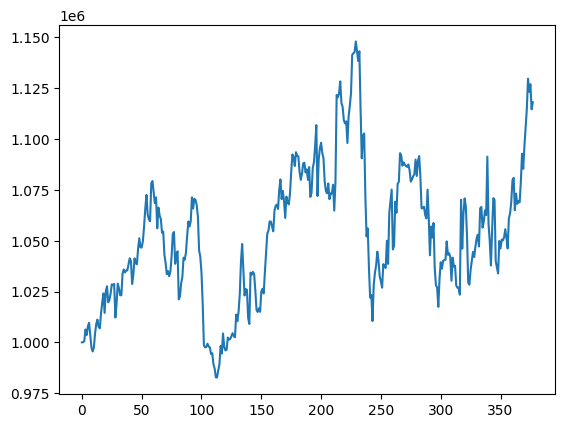

In [27]:
%matplotlib inline
df_account_value.account_value.plot()

<a id='8.1'></a>
## 8.1 BackTestStats
pass in df_account_value, this information is stored in env class

In [28]:
print("==============Get Backtest Results===========")
now = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

perf_stats_all = backtest_stats(account_value=df_account_value)
perf_stats_all = pd.DataFrame(perf_stats_all)

==============Get Backtest Results===========
Annual return          0.077207
Cumulative returns     0.118018
Annual volatility      0.144605
Sharpe ratio           0.587838
Calmar ratio           0.644861
Stability              0.193856
Max drawdown          -0.119727
Omega ratio            1.111512
Sortino ratio          0.841941
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.911860
Daily value at risk   -0.017881
dtype: float64


In [29]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI",
        start = df_account_value.loc[0,'date'],
        end = df_account_value.loc[len(df_account_value)-1,'date'])

stats = backtest_stats(df_dji_, value_col_name = 'close')

==============Get Baseline Stats===========


[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (377, 8)
Annual return          0.121020
Cumulative returns     0.186378
Annual volatility      0.153169
Sharpe ratio           0.824059
Calmar ratio           0.739314
Stability              0.545026
Max drawdown          -0.163692
Omega ratio            1.168892
Sortino ratio          1.218563
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.879382
Daily value at risk   -0.018797
dtype: float64


In [30]:
df_dji = pd.DataFrame()
df_dji['date'] = df_account_value['date']
df_dji['dji'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs["initial_amount"]
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji.csv")
df_dji = df_dji.set_index(df_dji.columns[0])
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji+.csv")

df_account_value.to_csv('df_account_value.csv')


df_dji:             date           dji
0    2024-01-03  1.000000e+06
1    2024-01-04  1.000271e+06
2    2024-01-05  1.000960e+06
3    2024-01-08  1.006754e+06
4    2024-01-09  1.002537e+06
..          ...           ...
373  2025-07-01  1.188745e+06
374  2025-07-02  1.188464e+06
375  2025-07-03  1.197657e+06
376  2025-07-07  1.186378e+06
377  2025-07-08           NaN

[378 rows x 2 columns]
df_dji:                       dji
date                    
2024-01-03  1.000000e+06
2024-01-04  1.000271e+06
2024-01-05  1.000960e+06
2024-01-08  1.006754e+06
2024-01-09  1.002537e+06
...                  ...
2025-07-01  1.188745e+06
2025-07-02  1.188464e+06
2025-07-03  1.197657e+06
2025-07-07  1.186378e+06
2025-07-08           NaN

[378 rows x 1 columns]


<a id='8.2'></a>
## 8.2 BackTestPlot

df_result_ensemble.columns:  Index(['ensemble'], dtype='object')
df_trade_date:         datadate
0    2023-10-03
1    2023-10-04
2    2023-10-05
3    2023-10-06
4    2023-10-09
..          ...
495  2025-09-24
496  2025-09-25
497  2025-09-26
498  2025-09-29
499  2025-09-30

[500 rows x 1 columns]
df_result_ensemble:                  ensemble
date                    
2024-01-03  1.000000e+06
2024-01-04  1.000048e+06
2024-01-05  1.000567e+06
2024-01-08  1.006321e+06
2024-01-09  1.003601e+06
...                  ...
2025-07-01  1.129657e+06
2025-07-02  1.123209e+06
2025-07-03  1.126906e+06
2025-07-07  1.114577e+06
2025-07-08  1.118018e+06

[378 rows x 1 columns]
==============Compare to DJIA===========
result:                  ensemble           dji
date                                  
2024-01-03  1.000000e+06  1.000000e+06
2024-01-04  1.000048e+06  1.000271e+06
2024-01-05  1.000567e+06  1.000960e+06
2024-01-08  1.006321e+06  1.006754e+06
2024-01-09  1.003601e+06  1.002537e+06
...       

<Axes: xlabel='date'>

<Figure size 1500x500 with 0 Axes>

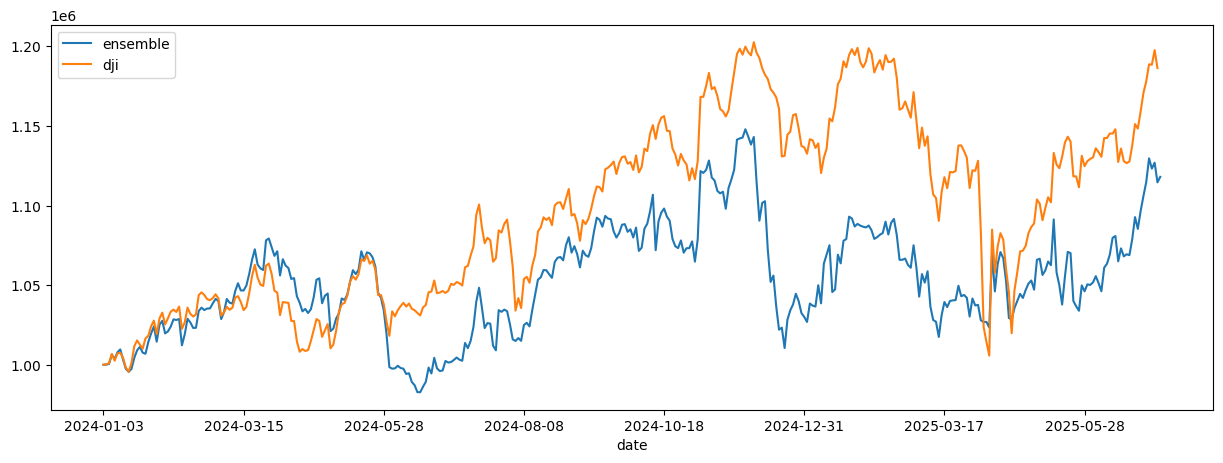

In [31]:

# print("==============Compare to DJIA===========")
# %matplotlib inline
# # S&P 500: ^GSPC
# # Dow Jones Index: ^DJI
# # NASDAQ 100: ^NDX
# backtest_plot(df_account_value,
#               baseline_ticker = '^DJI',
#               baseline_start = df_account_value.loc[0,'date'],
#               baseline_end = df_account_value.loc[len(df_account_value)-1,'date'])
df.to_csv("df.csv")
df_result_ensemble = pd.DataFrame({'date': df_account_value['date'], 'ensemble':df_account_value['account_value']})
df_result_ensemble = df_result_ensemble.set_index('date')

print("df_result_ensemble.columns: ", df_result_ensemble.columns)

print("df_trade_date: ", df_trade_date)
# df_result_ensemble['date'] = df_trade_date['datadate']
# df_result_ensemble['account_value'] = df_account_value['account_value']
df_result_ensemble.to_csv("df_result_ensemble.csv")
print("df_result_ensemble: ", df_result_ensemble)
print("==============Compare to DJIA===========")
result = pd.DataFrame()
# result = pd.merge(result, df_result_ensemble, left_index=True, right_index=True)

result = pd.merge(df_result_ensemble, df_dji, left_index=True, right_index=True)
print("result: ", result)
result.to_csv("result.csv")
result.columns = ['ensemble', 'dji']

%matplotlib inline
plt.rcParams["figure.figsize"] = (15, 5)
plt.figure()
result.plot()